<a href="https://colab.research.google.com/github/shahzodjabbarov/Football_Player_Value_Prediction-ML-Project-/blob/main/data_selection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/players_clean_no_missing.csv')

In [7]:
print(data)

                   Player Nation Position  Age  Matches Played  Starts  \
0           Mohamed Salah    EGY       AT   32              38      38   
1         Virgil van Dijk    NED       DF   33              37      37   
2        Ryan Gravenberch    NED       MT   22              37      37   
3     Alexis Mac Allister    ARG       MT   25              35      30   
4         Ibrahima Konaté    FRA       DF   25              31      30   
...                   ...    ...      ...  ...             ...     ...   
1907       Harvey Elliott    ENG       MT   21              18       2   
1908          Wataru Endo    JPN    MT,DF   31              20       1   
1909      Federico Chiesa    ITA       AT   26               6       1   
1910      Vitezslav Jaros    CZE       GB   23               1       0   
1911         Jayden Danns    ENG       MT   18               1       0   

     Minutes  90s Played  Goals  Assists  ...  npxG + xAG Per 90  \
0      3,371        37.5     29       18  .

In [6]:
print("data")

data


In [8]:
data = data.drop(['Player', 'name_clean', 'image_url', 'url'], axis=1)

In [9]:

y = data['market_value_in_eur']

# Remove target from features
X = data.drop(['market_value_in_eur', 'highest_market_value_in_eur'], axis=1)
# Note: highest_market_value might leak future info, so drop it

In [10]:
X.isnull().sum()

,0
Nation,0
Position,0
Age,0
Matches Played,0
Starts,0
Minutes,0
90s Played,0
Goals,0
Assists,0
Goals + Assists,0


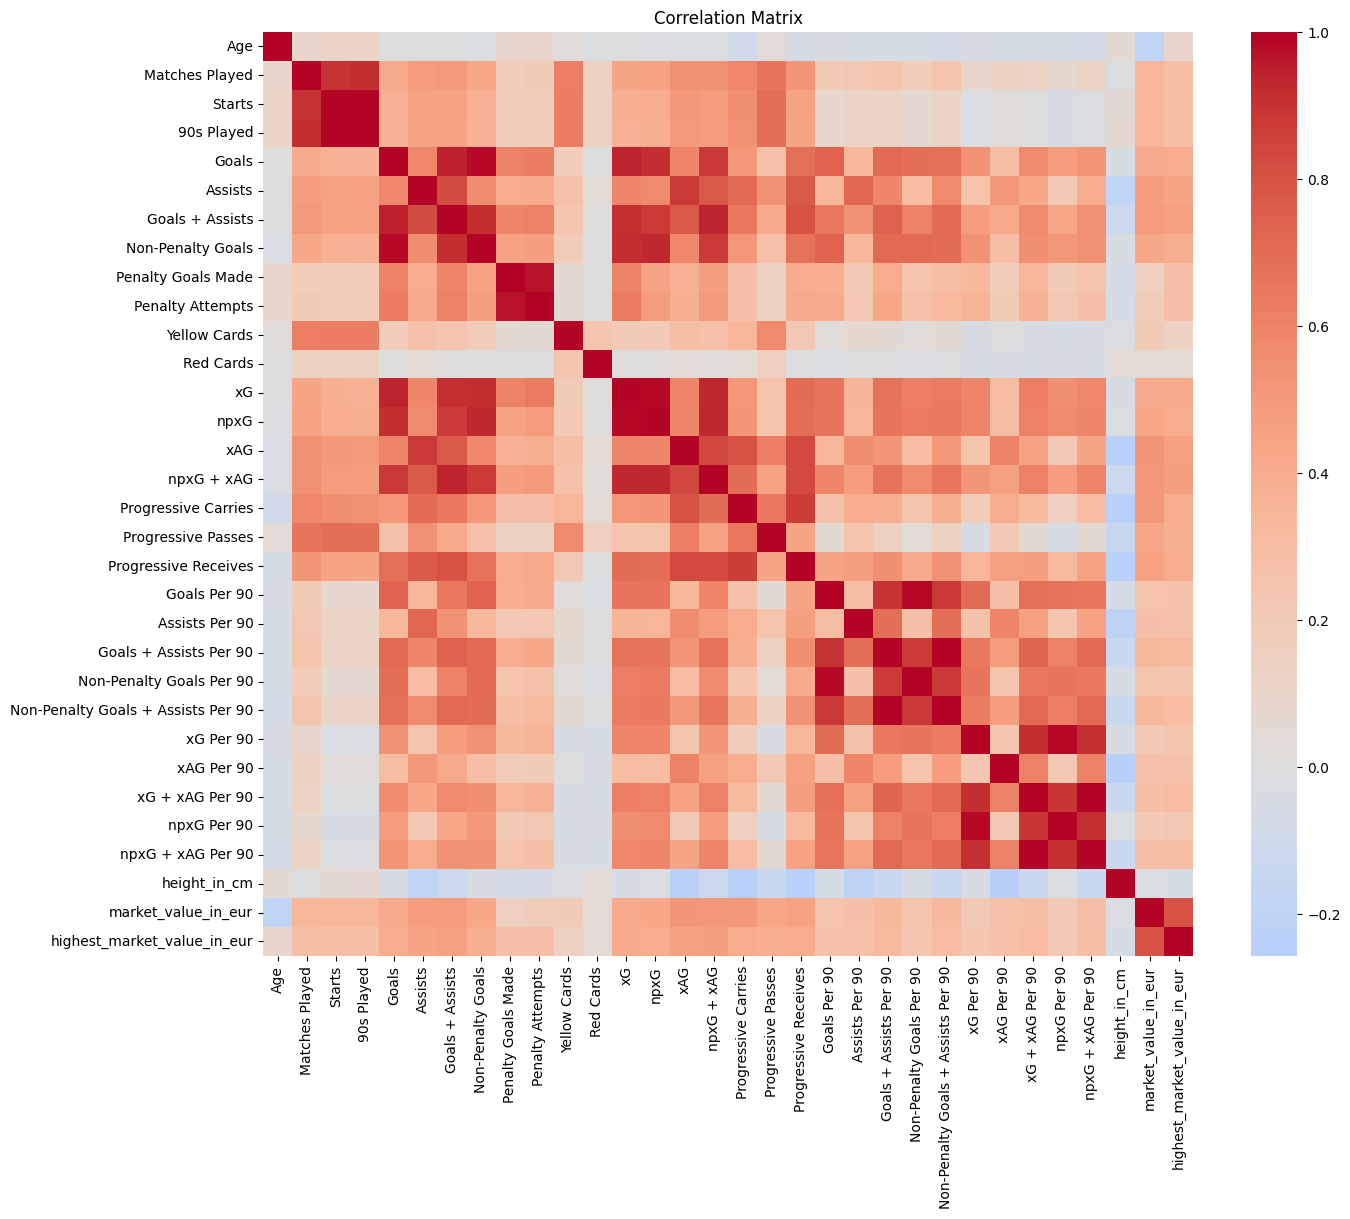

market_value_in_eur                   1.000000
highest_market_value_in_eur           0.800334
xAG                                   0.515070
npxG + xAG                            0.512531
Progressive Carries                   0.501733
Goals + Assists                       0.486898
Assists                               0.479836
Progressive Receives                  0.458899
Progressive Passes                    0.433475
Non-Penalty Goals                     0.424674
npxG                                  0.422563
Goals                                 0.410955
xG                                    0.408813
Matches Played                        0.351982
Starts                                0.349977
90s Played                            0.348709
Non-Penalty Goals + Assists Per 90    0.326348
Goals + Assists Per 90                0.325951
xG + xAG Per 90                       0.284092
npxG + xAG Per 90                     0.283004
Assists Per 90                        0.282461
xAG Per 90   

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

# Calculate correlations
corr_matrix = data[numerical_cols].corr()

# Visualize
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Or just look at correlations with target
corr_with_target = corr_matrix['market_value_in_eur'].sort_values(ascending=False)
print(corr_with_target)

In [12]:
# Your selected features
selected_features = [
    # Offensive output
    'npxG + xAG',

    # Ball progression
    'Progressive Carries',
    'Progressive Passes',
    'Progressive Receives',

    # Playing time
    '90s Played',
    'Starts',

    # Demographics
    'Age',
    'height_in_cm',

    # Categorical
    'Position',
    'Nation',
    'foot',
    'current_club_domestic_competition_id'
]

# Create your feature set
X = data[selected_features].copy()
y = data['market_value_in_eur'].copy()

# Verify
print(f"Total features: {len(selected_features)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nFeature names:")
print(X.columns.tolist())

Total features: 12
X shape: (1912, 12)
y shape: (1912,)

Feature names:
['npxG + xAG', 'Progressive Carries', 'Progressive Passes', 'Progressive Receives', '90s Played', 'Starts', 'Age', 'height_in_cm', 'Position', 'Nation', 'foot', 'current_club_domestic_competition_id']


In [14]:
print(X)

      npxG + xAG  Progressive Carries  Progressive Passes  \
0           32.4                  154                 144   
1            3.0                   22                 198   
2            4.2                   70                 181   
3            7.5                   36                 177   
4            2.7                   25                 115   
...          ...                  ...                 ...   
1907         2.8                   10                  44   
1908         0.1                    1                  19   
1909         0.5                    3                   3   
1910         0.0                    0                   0   
1911         0.0                    0                   0   

      Progressive Receives  90s Played  Starts  Age  height_in_cm Position  \
0                      488        37.5      38   32         175.0       AT   
1                        6        37.0      37   33         195.0       DF   
2                       55       

In [40]:
categorical_cols = [
    'Position',
    'foot'
]

for col in categorical_cols:
    print(f"Distinct values for '{col}':")
    print(X[col].unique())
    print("\n")

Distinct values for 'Position':
['AT' 'DF' 'MT' 'GB' 'MT,DF' 'MT,AT']


Distinct values for 'foot':
['left' 'right' 'both']




In [39]:
league_quality = {
    # Tier 5 - Elite leagues
    'GB1': 5,  # Premier League (England)

    # Tier 4 - Top leagues
    'ES1': 4,  # La Liga (Spain)
    'L1': 4,   # Bundesliga (Germany)
    'IT1': 4,  # Serie A (Italy)

    # Tier 3 - Strong leagues
    'FR1': 3,  # Ligue 1 (France)
    'NL1': 3,  # Eredivisie (Netherlands)
    'PO1': 3,  # Primeira Liga (Portugal)

    # Tier 2 - Mid-tier leagues
    'SC1': 2,  # Scottish Premiership
    'BE1': 2,  # Belgian Pro League
    'TR1': 2,  # Turkish Süper Lig
    'UKR1': 2, # Ukrainian Premier League

    # Tier 1 - Lower leagues
    'GR1': 1,  # Greek Super League
    'RU1': 1,  # Russian Premier League
}

# Apply the mapping
X['league_quality'] = X['current_club_domestic_competition_id'].map(league_quality)

# Then drop the original column
X = X.drop('current_club_domestic_competition_id', axis=1)

KeyError: 'current_club_domestic_competition_id'

In [19]:
print(X)

      npxG + xAG  Progressive Carries  Progressive Passes  \
0           32.4                  154                 144   
1            3.0                   22                 198   
2            4.2                   70                 181   
3            7.5                   36                 177   
4            2.7                   25                 115   
...          ...                  ...                 ...   
1907         2.8                   10                  44   
1908         0.1                    1                  19   
1909         0.5                    3                   3   
1910         0.0                    0                   0   
1911         0.0                    0                   0   

      Progressive Receives  90s Played  Starts  Age  height_in_cm Position  \
0                      488        37.5      38   32         175.0       AT   
1                        6        37.0      37   33         195.0       DF   
2                       55       

In [20]:
nation_talent_tier = {
    # Tier 5 - Elite football nations (consistently produce top players)
    'BRA': 5, 'ARG': 5, 'FRA': 5, 'ESP': 5, 'GER': 5, 'ENG': 5,
    'POR': 5, 'ITA': 5, 'NED': 5, 'BEL': 5,

    # Tier 4 - Strong football nations
    'URU': 4, 'COL': 4, 'CRO': 4, 'DEN': 4, 'SRB': 4,
    'POL': 4, 'SUI': 4, 'AUT': 4, 'SWE': 4, 'UKR': 4,
    'CZE': 4, 'TUR': 4, 'NOR': 4,

    # Tier 3 - Developing/mid-tier nations
    'MEX': 3, 'USA': 3, 'EGY': 3, 'NGA': 3, 'GHA': 3,
    'CIV': 3, 'SEN': 3, 'CMR': 3, 'MAR': 3, 'ALG': 3,
    'JPN': 3, 'KOR': 3, 'ECU': 3, 'CHI': 3, 'PAR': 3,
    'VEN': 3, 'SCO': 3, 'WAL': 3, 'IRL': 3, 'NIR': 3,
    'ROU': 3, 'GRE': 3, 'SVK': 3, 'SVN': 3, 'BIH': 3,
    'ISL': 3, 'FIN': 3, 'RUS': 3,

    # Tier 2 - Emerging nations
    'CAN': 2, 'AUS': 2, 'NZL': 2, 'JAM': 2, 'CRC': 2,
    'PER': 2, 'MLI': 2, 'BFA': 2, 'COD': 2, 'GUI': 2,
    'TUN': 2, 'KSA': 2, 'ALB': 2, 'UZB': 2, 'GEO': 2,
    'ANG': 2, 'CPV': 2, 'TOG': 2, 'BEN': 2, 'GAB': 2,
    'CGO': 2, 'SLE': 2, 'LTU': 2, 'EST': 2, 'KVX': 2,
    'CYP': 2, 'MNE': 2, 'ZIM': 2,
}

# For any nation not in the dictionary, assign tier 1 (default for rare nations)
X['nation_tier'] = X['Nation'].map(nation_talent_tier).fillna(1).astype(int)

# Then drop the original column
X = X.drop('Nation', axis=1)

In [27]:
print(X)

      npxG + xAG  Progressive Carries  Progressive Passes  \
0           32.4                  154                 144   
1            3.0                   22                 198   
2            4.2                   70                 181   
3            7.5                   36                 177   
4            2.7                   25                 115   
...          ...                  ...                 ...   
1907         2.8                   10                  44   
1908         0.1                    1                  19   
1909         0.5                    3                   3   
1910         0.0                    0                   0   
1911         0.0                    0                   0   

      Progressive Receives  90s Played  Starts  Age  height_in_cm Position  \
0                      488        37.5      38   32         175.0       AT   
1                        6        37.0      37   33         195.0       DF   
2                       55       

In [53]:
import numpy as np

y_log = np.log(y)


In [55]:
print(y_log)

0       17.822844
1       17.147715
2       18.064006
3       18.315320
4       17.909855
          ...    
1907    17.370859
1908    16.118096
1909    16.705882
1910    15.424948
1911    13.815511
Name: market_value_in_eur, Length: 1912, dtype: float64


In [56]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)


In [57]:

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

preprocessing.fit(X_train)




ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['npxG + xAG', 'Progressive Carries',
                                  'Progressive Passes', 'Progressive Receives',
                                  '90s Played', 'Starts', 'Age', 'height_in_cm',
                                  'league_quality', 'nation_tier']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Position', 'foot'])])

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])




In [60]:
full_pipeline.fit(X_train, y_train_log)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['npxG + xAG',
                                                   'Progressive Carries',
                                                   'Progressive Passes',
                                                   'Progressive Receives',
                                                   '90s Played', 'Starts',
                                                   'Age', 'height_in_cm',
                                                   'league_quality',
                                                   'nation_tier']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Position', 'foot'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [61]:
predictions_log = full_pipeline.predict(X_test)
import numpy as np

predictions = np.exp(predictions_log)
y_test_actual = np.exp(y_test_log)
print(predictions[:5])
print(y_test_actual.values[:5])


[ 5479384.88569741 29099781.78623589   999999.99999997  2770244.6698431
  4239699.07943607]
[ 4000000.         29999999.99999995  1000000.          1000000.
  8999999.99999999]


In [64]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, predictions)
mape = mean_absolute_percentage_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print(f"MAE:  €{mae:,.0f}")
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: €{rmse:,.0f}")


MAE:  €5,029,601
MAPE: 84.41%
RMSE: €10,522,600


In [65]:
import pandas as pd

errors_df = X_test.copy()
errors_df['actual'] = y_test_actual.values
errors_df['pred'] = predictions
errors_df['abs_error'] = abs(errors_df['pred'] - errors_df['actual'])
errors_df['pct_error'] = errors_df['abs_error'] / errors_df['actual']


In [66]:
errors_df.sort_values('abs_error', ascending=False).head(10)


,npxG + xAG,Progressive Carries,Progressive Passes,Progressive Receives,90s Played,Starts,Age,height_in_cm,Position,foot,league_quality,nation_tier,actual,pred,abs_error,pct_error
439,0.2,4,8,11,1.3,1,24,191.0,AT,right,5,5,130000000.0,8.898106e+06,1.211019e+08,0.931553
354,2.4,13,77,42,12.1,14,19,173.0,"MT,AT",right,4,5,70000000.0,8.626683e+06,6.137332e+07,0.876762
351,3.9,107,93,246,25.4,26,20,175.0,DF,left,4,5,60000000.0,9.335949e+06,5.066405e+07,0.844401
78,1.1,0,7,0,4.6,6,24,195.0,DF,left,5,5,45000000.0,8.687108e+06,3.631289e+07,0.806953
254,0.1,0,1,2,0.2,0,27,191.0,MT,right,4,3,40000000.0,3.890098e+06,3.610990e+07,0.902748
49,3.1,16,138,6,33.8,35,23,192.0,DF,right,5,5,80000000.0,4.491663e+07,3.508337e+07,0.438542
231,16.1,77,325,129,33.5,35,29,179.0,MT,right,5,5,55000000.0,2.038956e+07,3.461044e+07,0.629281
259,0.0,0,1,0,24.0,24,27,194.0,GB,right,5,5,35000000.0,5.036191e+06,2.996381e+07,0.856109
694,5.2,16,121,33,26.6,28,20,187.0,MT,right,4,4,40000000.0,1.256179e+07,2.743821e+07,0.685955
324,7.0,76,145,108,32.3,34,20,178.0,MT,right,5,5,15000000.0,4.239811e+07,2.739811e+07,1.826541


In [67]:
errors_df.sort_values('pct_error', ascending=False).head(10)


,npxG + xAG,Progressive Carries,Progressive Passes,Progressive Receives,90s Played,Starts,Age,height_in_cm,Position,foot,league_quality,nation_tier,actual,pred,abs_error,pct_error
413,1.8,7,81,3,28.0,29,30,180.0,DF,right,3,5,100000.0,3.859944e+06,3.759944e+06,37.599436
322,0.0,0,6,1,2.2,2,31,176.0,MT,right,5,2,500000.0,5.109249e+06,4.609249e+06,9.218499
1655,2.6,18,54,51,11.6,12,22,180.0,MT,right,3,5,800000.0,6.582102e+06,5.782102e+06,7.227627
917,0.0,0,0,0,25.0,25,25,191.0,GB,both,4,5,1500000.0,1.155785e+07,1.005785e+07,6.705236
1614,0.0,0,0,0,16.0,16,33,187.0,GB,left,3,5,200000.0,1.533886e+06,1.333886e+06,6.669432
251,0.2,1,7,1,1.9,2,17,189.0,DF,left,5,5,1500000.0,1.091539e+07,9.415387e+06,6.276925
1302,0.2,8,5,19,2.1,0,22,181.0,"MT,AT",right,4,4,500000.0,3.239336e+06,2.739336e+06,5.478673
1350,0.0,1,9,1,4.0,3,25,193.0,DF,right,4,4,600000.0,3.808491e+06,3.208491e+06,5.347484
1684,0.1,3,2,2,0.9,1,17,182.0,"MT,AT",left,3,5,300000.0,1.885392e+06,1.585392e+06,5.284639
1392,0.0,3,2,5,1.1,1,18,174.0,"MT,AT",right,3,5,200000.0,1.204051e+06,1.004051e+06,5.020254


In [68]:
errors_df.groupby('Position')['pct_error'].mean()


,pct_error
Position,
AT,0.387761
DF,0.906773
GB,1.309432
MT,0.851281
"MT,AT",1.010621
"MT,DF",0.389665


In [69]:
errors_df.groupby('league_quality')['pct_error'].mean()


,pct_error
league_quality,
1,0.332003
2,0.386644
3,1.415194
4,0.724864
5,0.614244


In [70]:
errors_df.groupby('nation_tier')['pct_error'].mean()


,pct_error
nation_tier,
1,0.423479
2,1.083251
3,0.580593
4,0.761905
5,0.924766


In [71]:
for pos in data['Position'].unique():
    sub = data[data['Position']==pos]


In [72]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=500,
    min_samples_leaf=20,
    random_state=42
)


In [74]:
# Apply the preprocessing pipeline to X_train before fitting the model
X_train_processed = preprocessing.transform(X_train)
model.fit(X_train_processed, y_train_log)

HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=500,
                              random_state=42)

In [76]:
# Preprocess X_test using the same ColumnTransformer fitted on X_train
X_test_processed = preprocessing.transform(X_test)

pred_log = model.predict(X_test_processed)
# Use np.exp for inverse transformation as y was transformed with np.log
pred = np.exp(pred_log)

In [77]:
param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [300, 500, 800],
    "min_samples_leaf": [10, 20, 50]
}


In [79]:
# by position
errors_df.groupby('Position')['pct_error'].mean()

# by value bucket
errors_df.groupby(pd.cut(errors_df['actual'], bins=[0,1e6,5e6,20e6,100e6,np.inf]))['pct_error'].mean()

/tmp/ipython-input-1859136325.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  errors_df.groupby(pd.cut(errors_df['actual'], bins=[0,1e6,5e6,20e6,100e6,np.inf]))['pct_error'].mean()


,pct_error
actual,
"(0.0, 1000000.0]",3.229113
"(1000000.0, 5000000.0]",0.824596
"(5000000.0, 20000000.0]",0.399989
"(20000000.0, 100000000.0]",0.388708
"(100000000.0, inf]",0.931553
